# Olist E-Commerce Operations & Customer Experience Analysis

## Exploratory Data Analysis

This notebook explores the operational and customer-experience performance of the Olist e-commerce marketplace using the cleaned and validated datasets produced in the data preparation stage.

The analysis focuses on:

- Order volume and status distribution
- Delivery speed and late-delivery performance
- Customer review behavior and satisfaction
- Relationship between delivery performance and review scores
- Geographic differences in operations
- Product-category performance
- Seller performance
- Payment and transaction patterns
- Repeat-customer behavior

The objective is to identify operational bottlenecks and customer-experience patterns that can support business decisions and later Power BI dashboard development.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

Matplotlib is building the font cache; this may take a moment.


## 1. Load Processed Data

The analysis uses the cleaned datasets generated during the data preparation stage. We begin with the order-level fact table, which contains one row per order and combines operational, customer, payment, item, and review-level metrics.

In [3]:
fact_orders = pd.read_csv(
    "../Data/processed/fact_orders.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

print("Rows:", fact_orders.shape[0])
print("Columns:", fact_orders.shape[1])

Rows: 99441
Columns: 35


In [4]:
fact_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
 8   delivery_time_days             96476 non-null  float64       
 9   delivery_delay_days            96476 non-null  float64       
 10  is_late                        96470 non-null  object        
 11  carrier_handoff_days      

In [5]:
fact_orders["is_late"] = fact_orders["is_late"].astype("boolean")
fact_orders["has_review_comment"] = fact_orders["has_review_comment"].astype("boolean")

print(fact_orders[["is_late", "has_review_comment"]].dtypes)

is_late               boolean
has_review_comment    boolean
dtype: object


## 2. Dataset Time Coverage

Before evaluating operational performance, we first examine the time period represented in the dataset. This helps distinguish complete periods from partial periods when interpreting order-volume trends.

In [6]:
start_date = fact_orders["order_purchase_timestamp"].min()
end_date = fact_orders["order_purchase_timestamp"].max()

print("First order:", start_date)
print("Last order:", end_date)
print("Time span:", end_date - start_date)

First order: 2016-09-04 21:15:19
Last order: 2018-10-17 17:30:18
Time span: 772 days 20:14:59


## 3. Order Volume & Status

We begin by examining the distribution of order statuses to understand overall order completion and identify operational exceptions such as cancellations and unavailable orders.

In [7]:
order_status_summary = (
    fact_orders["order_status"]
    .value_counts()
    .to_frame("order_count")
)

order_status_summary["percentage"] = (
    order_status_summary["order_count"]
    / len(fact_orders)
    * 100
).round(2)

order_status_summary

,order_count,percentage
order_status,,
delivered,96478,97.02
shipped,1107,1.11
canceled,625,0.63
unavailable,609,0.61
invoiced,314,0.32
processing,301,0.30
created,5,0.01
approved,2,0.00


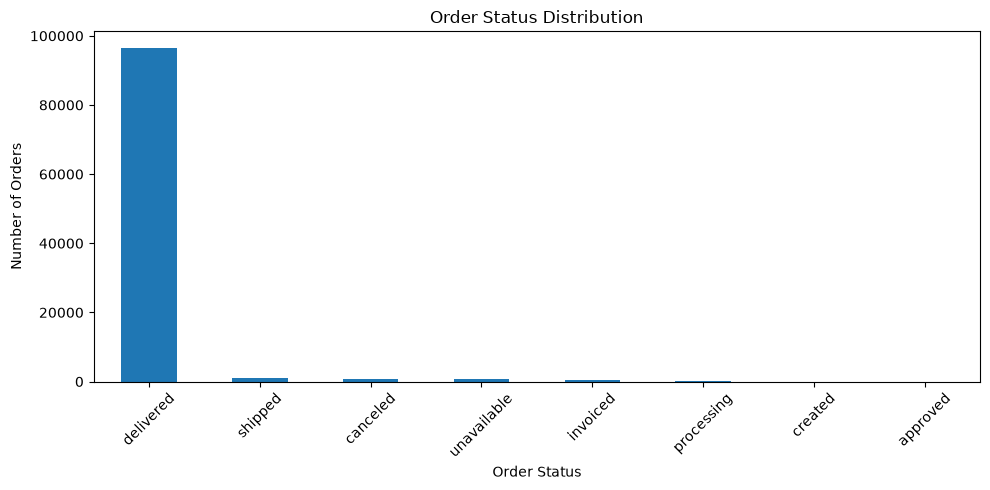

In [8]:
plt.figure(figsize=(10, 5))

order_status_summary["order_count"].plot(kind="bar")

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Monthly Order Volume

Monthly order volume is analyzed to identify growth patterns, seasonality, unusual spikes, and changes in marketplace activity over time. Partial months at the beginning and end of the dataset should be interpreted cautiously.

In [9]:
monthly_orders = (
    fact_orders
    .set_index("order_purchase_timestamp")
    .resample("MS")
    .size()
    .rename("order_count")
    .reset_index()
)

monthly_orders

,order_purchase_timestamp,order_count
0,2016-09-01,4
1,2016-10-01,324
2,2016-11-01,0
3,2016-12-01,1
4,2017-01-01,800
5,2017-02-01,1780
6,2017-03-01,2682
7,2017-04-01,2404
8,2017-05-01,3700
9,2017-06-01,3245


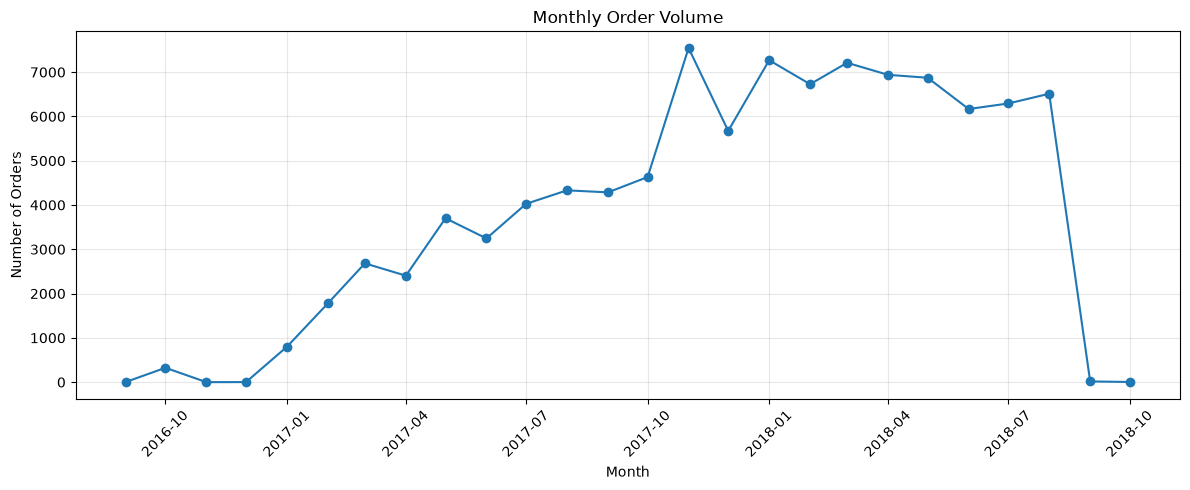

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_orders["order_purchase_timestamp"],
    monthly_orders["order_count"],
    marker="o"
)

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

## 4. Delivery Performance

Delivery performance is a key operational and customer-experience metric. This section evaluates delivery speed, estimated delivery windows, and the frequency and severity of late deliveries.

To maintain a consistent KPI definition, late-delivery analysis is restricted to completed delivered orders with both actual and estimated delivery dates available.

In [11]:
delivered_orders = fact_orders[
    (fact_orders["order_status"] == "delivered")
    & fact_orders["order_delivered_customer_date"].notna()
].copy()

print("Delivered orders:", len(delivered_orders))
print("Orders with measurable late status:", delivered_orders["is_late"].notna().sum())
print("Orders without measurable late status:", delivered_orders["is_late"].isna().sum())

Delivered orders: 96470
Orders with measurable late status: 96470
Orders without measurable late status: 0


In [12]:
delivery_kpis = {
    "Delivered Orders Analyzed": len(delivered_orders),
    "Average Delivery Time (Days)": delivered_orders["delivery_time_days"].mean(),
    "Median Delivery Time (Days)": delivered_orders["delivery_time_days"].median(),
    "Average Delivery Delay (Days)": delivered_orders["delivery_delay_days"].mean(),
    "Late Orders": delivered_orders["is_late"].sum(),
    "Late Delivery Rate (%)": delivered_orders["is_late"].mean() * 100
}

pd.Series(delivery_kpis).round(2)

Delivered Orders Analyzed        96470.00
Average Delivery Time (Days)        12.56
Median Delivery Time (Days)         10.22
Average Delivery Delay (Days)      -11.18
Late Orders                       7826.00
Late Delivery Rate (%)               8.11
dtype: float64

In [13]:
late_orders = delivered_orders[
    delivered_orders["is_late"] == True
].copy()

late_orders["delivery_delay_days"].describe().round(2)

count    7826.00
mean        9.55
std        13.95
min         0.00
25%         1.87
50%         5.81
75%        11.82
max       188.98
Name: delivery_delay_days, dtype: float64

In [14]:
late_orders["delay_severity"] = pd.cut(
    late_orders["delivery_delay_days"],
    bins=[-0.001, 3, 7, 14, 30, np.inf],
    labels=[
        "0–3 days",
        "4–7 days",
        "8–14 days",
        "15–30 days",
        "30+ days"
    ]
)

delay_severity_summary = (
    late_orders["delay_severity"]
    .value_counts(sort=False)
    .to_frame("late_order_count")
)

delay_severity_summary["percentage"] = (
    delay_severity_summary["late_order_count"]
    / len(late_orders)
    * 100
).round(2)

delay_severity_summary

,late_order_count,percentage
delay_severity,,
0–3 days,2662,34.01
4–7 days,1819,23.24
8–14 days,1790,22.87
15–30 days,1195,15.27
30+ days,360,4.60


## 5. Delivery Performance & Customer Experience

To evaluate the customer-experience impact of operational performance, we compare review scores between on-time and late deliveries.

Only delivered orders with a measurable late-delivery status and an available review score are included in this analysis.

In [15]:
delivery_review = delivered_orders[
    delivered_orders["latest_review_score"].notna()
].copy()

review_by_delivery = (
    delivery_review
    .groupby("is_late", observed=True)
    .agg(
        order_count=("order_id", "count"),
        average_review_score=("latest_review_score", "mean"),
        median_review_score=("latest_review_score", "median")
    )
)

review_by_delivery.round(2)

,order_count,average_review_score,median_review_score
is_late,,,
False,88163,4.29,5.0
True,7661,2.57,2.0


In [16]:
late_review_by_severity = (
    late_orders[
        late_orders["latest_review_score"].notna()
    ]
    .groupby("delay_severity", observed=True)
    .agg(
        order_count=("order_id", "count"),
        average_review_score=("latest_review_score", "mean"),
        median_review_score=("latest_review_score", "median")
    )
)

late_review_by_severity.round(2)

,order_count,average_review_score,median_review_score
delay_severity,,,
0–3 days,2636,3.77,4.0
4–7 days,1773,2.32,1.0
8–14 days,1748,1.74,1.0
15–30 days,1161,1.61,1.0
30+ days,343,2.03,1.0


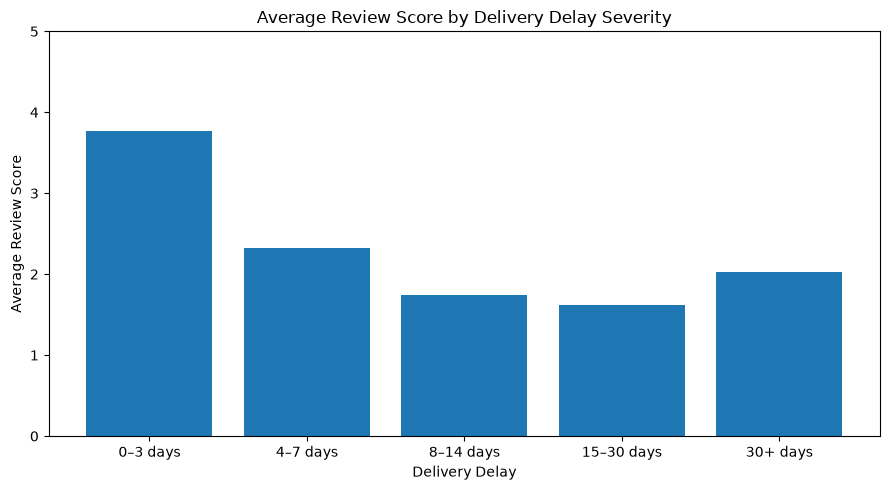

In [17]:
plt.figure(figsize=(9, 5))

plt.bar(
    late_review_by_severity.index.astype(str),
    late_review_by_severity["average_review_score"]
)

plt.title("Average Review Score by Delivery Delay Severity")
plt.xlabel("Delivery Delay")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)
plt.tight_layout()

plt.show()

### Delivery Process Breakdown

To better understand where delivery time is spent, the delivery process is separated into two stages:

- **Carrier handoff time:** time from order purchase until the order is handed to the carrier.
- **Carrier transit time:** time from carrier handoff until delivery to the customer.

Comparing these stages helps identify whether delivery delays are more strongly associated with pre-shipping processing or transportation.

In [18]:
delivery_stage_summary = (
    delivered_orders[
        ["carrier_handoff_days", "carrier_transit_days"]
    ]
    .describe()
    .loc[["count", "mean", "50%", "75%", "max"]]
    .round(2)
)

delivery_stage_summary

,carrier_handoff_days,carrier_transit_days
count,96304.00,96446.00
mean,3.23,9.33
50%,2.21,7.10
75%,4.07,12.03
max,125.78,205.19


In [19]:
delivery_stage_by_late = (
    delivered_orders
    .groupby("is_late", observed=True)
    .agg(
        order_count=("order_id", "count"),
        avg_handoff_days=("carrier_handoff_days", "mean"),
        median_handoff_days=("carrier_handoff_days", "median"),
        avg_transit_days=("carrier_transit_days", "mean"),
        median_transit_days=("carrier_transit_days", "median")
    )
)

delivery_stage_by_late.round(2)

,order_count,avg_handoff_days,median_handoff_days,avg_transit_days,median_transit_days
is_late,,,,,
False,88644,3.00,2.14,7.89,6.92
True,7826,5.84,3.44,25.68,23.92


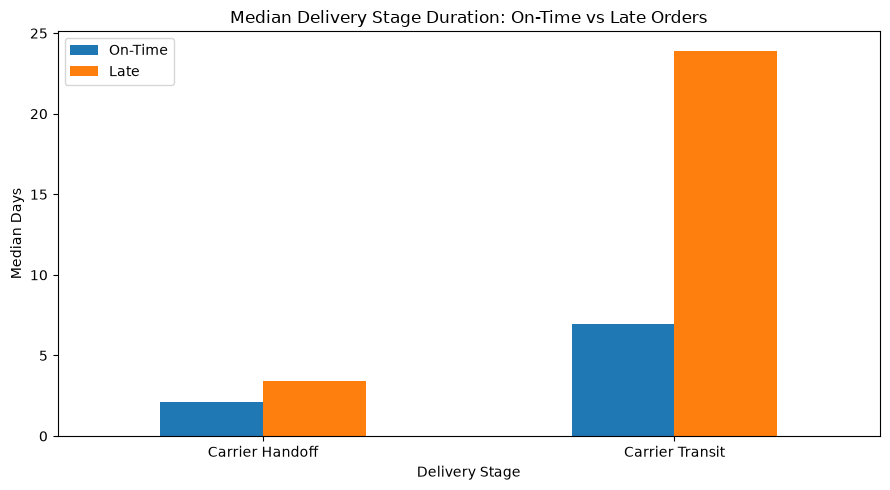

In [20]:
stage_comparison = pd.DataFrame({
    "On-Time": [
        delivery_stage_by_late.loc[False, "median_handoff_days"],
        delivery_stage_by_late.loc[False, "median_transit_days"]
    ],
    "Late": [
        delivery_stage_by_late.loc[True, "median_handoff_days"],
        delivery_stage_by_late.loc[True, "median_transit_days"]
    ]
}, index=["Carrier Handoff", "Carrier Transit"])

stage_comparison.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Median Delivery Stage Duration: On-Time vs Late Orders")
plt.xlabel("Delivery Stage")
plt.ylabel("Median Days")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

## 6. Geographic Delivery Performance

Delivery performance may vary across customer regions due to distance, logistics infrastructure, and marketplace coverage.

This section compares order volume, delivery speed, late-delivery rate, and customer satisfaction across Brazilian states. To avoid misleading conclusions from very small samples, regional comparisons should consider order volume alongside performance metrics.

In [21]:
state_performance = (
    delivered_orders
    .groupby("customer_state")
    .agg(
        delivered_orders=("order_id", "count"),
        late_orders=("is_late", "sum"),
        late_rate=("is_late", "mean"),
        median_delivery_days=("delivery_time_days", "median"),
        average_review_score=("latest_review_score", "mean")
    )
    .reset_index()
)

state_performance["late_rate_pct"] = (
    state_performance["late_rate"] * 100
)

state_performance = (
    state_performance
    .sort_values("delivered_orders", ascending=False)
)

state_performance.round(2)

,customer_state,delivered_orders,late_orders,late_rate,median_delivery_days,average_review_score,late_rate_pct
25,SP,40494,2387,0.06,7.21,4.25,5.89
18,RJ,12350,1664,0.13,12.04,3.97,13.47
10,MG,11354,637,0.06,10.31,4.19,5.61
22,RS,5344,382,0.07,13.18,4.18,7.15
17,PR,4923,246,0.05,10.43,4.24,5.0
23,SC,3546,346,0.1,13.01,4.13,9.76
4,BA,3256,457,0.14,16.91,3.93,14.04
6,DF,2080,147,0.07,11.36,4.13,7.07
7,ES,1995,244,0.12,13.64,4.08,12.23
8,GO,1957,160,0.08,13.95,4.10,8.18


In [22]:
state_performance_filtered = (
    state_performance[
        state_performance["delivered_orders"] >= 300
    ]
    .sort_values("late_rate_pct", ascending=False)
)

state_performance_filtered[
    [
        "customer_state",
        "delivered_orders",
        "late_rate_pct",
        "median_delivery_days",
        "average_review_score"
    ]
].round(2)

,customer_state,delivered_orders,late_rate_pct,median_delivery_days,average_review_score
1,AL,397,23.93,22.33,3.85
9,MA,717,19.67,19.19,3.83
16,PI,476,15.97,16.29,3.99
5,CE,1279,15.32,18.21,3.94
24,SE,335,15.22,18.01,3.91
4,BA,3256,14.04,16.91,3.93
18,RJ,12350,13.47,12.04,3.97
13,PA,946,12.37,21.08,3.91
7,ES,1995,12.23,13.64,4.08
11,MS,701,11.55,13.94,4.16


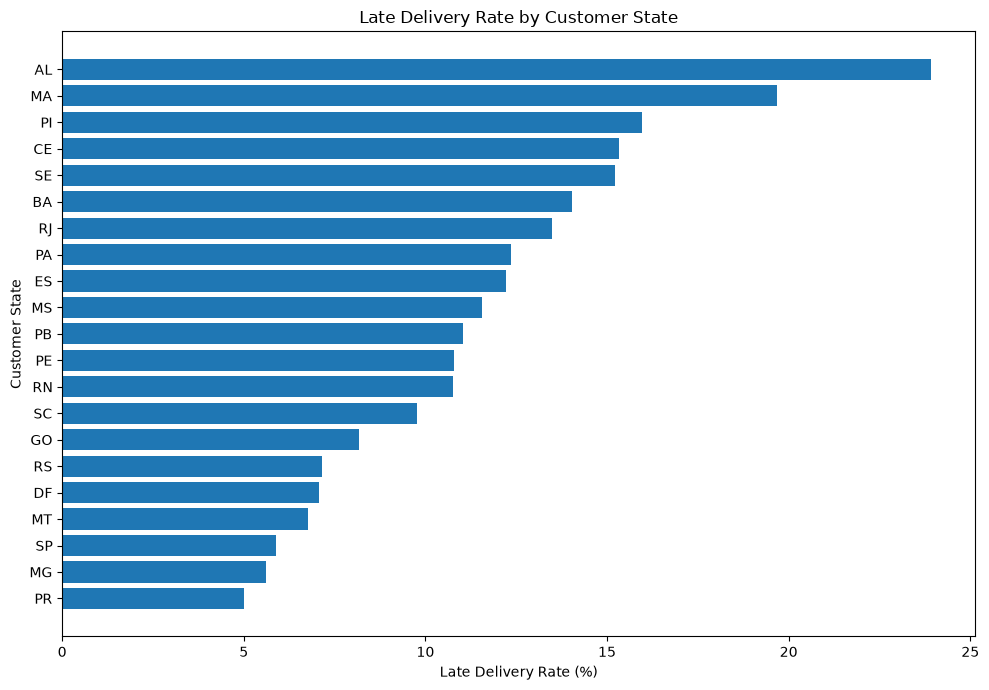

In [23]:
state_late_chart = (
    state_performance_filtered
    .sort_values("late_rate_pct", ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    state_late_chart["customer_state"],
    state_late_chart["late_rate_pct"]
)

plt.title("Late Delivery Rate by Customer State")
plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Customer State")
plt.tight_layout()

plt.show()

## 7. Product Category Performance

Product categories may differ in order volume, transaction value, delivery performance, and customer satisfaction.

Because products are recorded at the order-item level, category analysis is performed using the cleaned order-item and product datasets. Care is taken to preserve the correct analytical grain and avoid duplicating order-level metrics.

In [24]:
fact_order_items = pd.read_csv(
    "../Data/processed/fact_order_items.csv"
)

dim_products = pd.read_csv(
    "../Data/processed/dim_products.csv"
)

print("Order item rows:", len(fact_order_items))
print("Product rows:", len(dim_products))
print("Unique products in order items:", fact_order_items["product_id"].nunique())
print("Unique products in product dimension:", dim_products["product_id"].nunique())

Order item rows: 112650
Product rows: 32951
Unique products in order items: 32951
Unique products in product dimension: 32951


In [25]:
items_with_products = fact_order_items.merge(
    dim_products[
        ["product_id", "product_category_name_english"]
    ],
    on="product_id",
    how="left",
    validate="many_to_one"
)

print("Rows before merge:", len(fact_order_items))
print("Rows after merge:", len(items_with_products))
print(
    "Missing product categories:",
    items_with_products["product_category_name_english"].isna().sum()
)
print(
    "Unique categories:",
    items_with_products["product_category_name_english"].nunique()
)

Rows before merge: 112650
Rows after merge: 112650
Missing product categories: 0
Unique categories: 74


In [26]:
category_summary = (
    items_with_products
    .groupby("product_category_name_english")
    .agg(
        item_count=("order_item_id", "count"),
        unique_orders=("order_id", "nunique"),
        total_item_price=("price", "sum"),
        total_freight_value=("freight_value", "sum"),
        total_transaction_value=("item_total_value", "sum")
    )
    .reset_index()
    .sort_values("unique_orders", ascending=False)
)

category_summary.head(15).round(2)

,product_category_name_english,item_count,unique_orders,total_item_price,total_freight_value,total_transaction_value
10,bed_bath_table,11115,9417,1036988.68,204693.04,1241681.72
46,health_beauty,9670,8836,1258681.34,182566.73,1441248.07
68,sports_leisure,8641,7720,988048.97,168607.51,1156656.48
18,computers_accessories,7827,6689,911954.32,147318.08,1059272.40
42,furniture_decor,8334,6449,729762.49,172749.30,902511.79
52,housewares,6964,5884,632248.66,146149.11,778397.77
73,watches_gifts,5991,5624,1205005.68,100535.93,1305541.61
71,telephony,4545,4199,323667.53,71215.79,394883.32
8,auto,4235,3897,592720.11,92664.21,685384.32
72,toys,4117,3886,483946.60,77425.95,561372.55


In [27]:
order_category = (
    items_with_products[
        ["order_id", "product_category_name_english"]
    ]
    .drop_duplicates()
)

print("Order-item rows:", len(items_with_products))
print("Unique order-category rows:", len(order_category))
print(
    "Unique orders represented:",
    order_category["order_id"].nunique()
)

Order-item rows: 112650
Unique order-category rows: 99470
Unique orders represented: 98666


In [29]:
category_order_performance = order_category.merge(
    fact_orders[
        [
            "order_id",
            "order_status",
            "delivery_time_days",
            "is_late",
            "latest_review_score"
        ]
    ],
    on="order_id",
    how="left",
    validate="many_to_one"
)

print("Rows before merge:", len(order_category))
print("Rows after merge:", len(category_order_performance))
print(
    "Missing matched orders:",
    category_order_performance["order_status"].isna().sum()
)

Rows before merge: 99470
Rows after merge: 99470
Missing matched orders: 0


In [30]:
category_delivery = category_order_performance[
    (category_order_performance["order_status"] == "delivered")
    & category_order_performance["is_late"].notna()
].copy()

category_performance = (
    category_delivery
    .groupby("product_category_name_english")
    .agg(
        delivered_orders=("order_id", "count"),
        late_orders=("is_late", "sum"),
        late_rate=("is_late", "mean"),
        median_delivery_days=("delivery_time_days", "median"),
        average_review_score=("latest_review_score", "mean")
    )
    .reset_index()
)

category_performance["late_rate_pct"] = (
    category_performance["late_rate"] * 100
)

category_performance.sort_values(
    "delivered_orders",
    ascending=False
).head(15).round(2)

,product_category_name_english,delivered_orders,late_orders,late_rate,median_delivery_days,average_review_score,late_rate_pct
10,bed_bath_table,9272,811,0.09,10.71,4.00,8.75
46,health_beauty,8647,775,0.09,9.55,4.23,8.96
68,sports_leisure,7529,584,0.08,10.11,4.23,7.76
18,computers_accessories,6529,503,0.08,11.10,4.08,7.7
42,furniture_decor,6307,535,0.08,10.87,4.06,8.48
52,housewares,5743,399,0.07,8.93,4.19,6.95
73,watches_gifts,5493,468,0.09,10.34,4.12,8.52
71,telephony,4093,349,0.09,10.81,4.05,8.53
8,auto,3809,328,0.09,9.74,4.15,8.61
72,toys,3803,286,0.08,9.41,4.24,7.52


In [31]:
category_performance_filtered = (
    category_performance[
        category_performance["delivered_orders"] >= 300
    ]
    .sort_values("late_rate_pct", ascending=False)
)

category_performance_filtered[
    [
        "product_category_name_english",
        "delivered_orders",
        "late_rate_pct",
        "median_delivery_days",
        "average_review_score"
    ]
].head(15).round(2)

,product_category_name_english,delivered_orders,late_rate_pct,median_delivery_days,average_review_score
7,audio,348,12.93,10.78,3.84
50,home_confort,392,10.46,11.45,3.88
39,food,441,9.98,7.15,4.33
29,electronics,2517,9.81,10.99,4.12
9,baby,2809,9.18,10.05,4.10
60,office_furniture,1254,9.17,18.86,3.64
2,Unknown,1392,9.12,10.67,4.01
20,construction_tools_construction,736,9.1,8.70,4.13
46,health_beauty,8647,8.96,9.55,4.23
59,musical_instruments,611,8.84,10.38,4.23


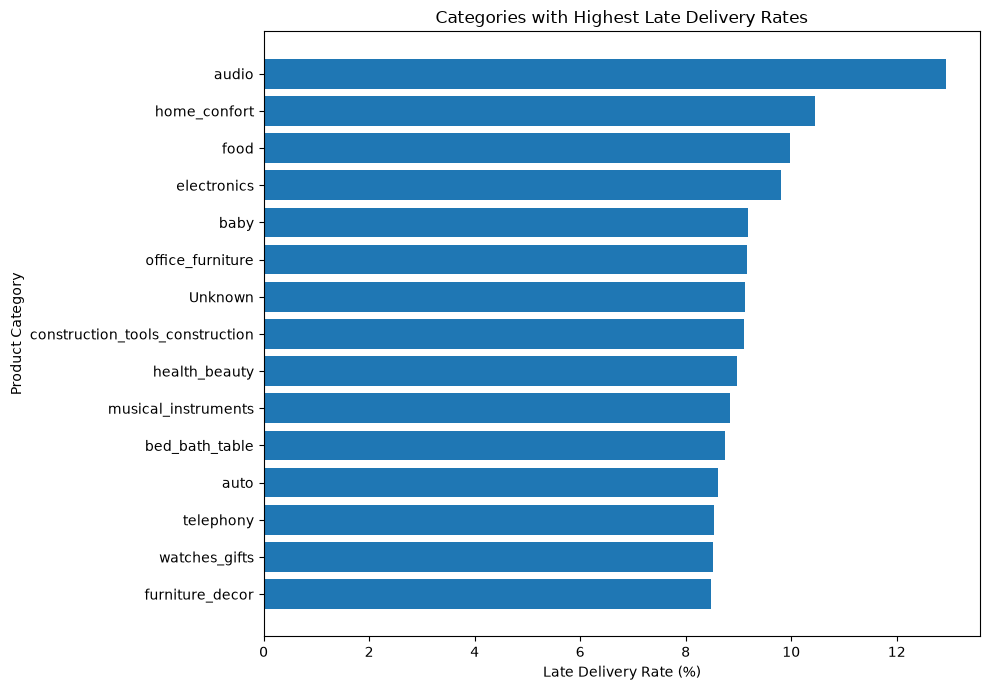

In [32]:
category_late_chart = (
    category_performance_filtered
    .head(15)
    .sort_values("late_rate_pct", ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    category_late_chart["product_category_name_english"],
    category_late_chart["late_rate_pct"]
)

plt.title("Categories with Highest Late Delivery Rates")
plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Product Category")
plt.tight_layout()

plt.show()

## 8. Seller Performance

Seller-level analysis helps identify marketplace partners associated with high order volume and weaker operational or customer-experience outcomes.

Because some orders contain products from multiple sellers, order-level delivery and review outcomes cannot always be attributed exclusively to a single seller. Therefore, seller performance in this analysis should be interpreted as performance associated with orders containing that seller rather than direct causal responsibility.

In [33]:
order_seller = (
    fact_order_items[
        ["order_id", "seller_id"]
    ]
    .drop_duplicates()
)

print("Order-item rows:", len(fact_order_items))
print("Unique order-seller rows:", len(order_seller))
print("Unique orders represented:", order_seller["order_id"].nunique())
print("Unique sellers represented:", order_seller["seller_id"].nunique())

Order-item rows: 112650
Unique order-seller rows: 100010
Unique orders represented: 98666
Unique sellers represented: 3095


In [34]:
seller_order_performance = order_seller.merge(
    fact_orders[
        [
            "order_id",
            "order_status",
            "delivery_time_days",
            "is_late",
            "latest_review_score"
        ]
    ],
    on="order_id",
    how="left",
    validate="many_to_one"
)

print("Rows before merge:", len(order_seller))
print("Rows after merge:", len(seller_order_performance))
print(
    "Missing matched orders:",
    seller_order_performance["order_status"].isna().sum()
)

Rows before merge: 100010
Rows after merge: 100010
Missing matched orders: 0


In [35]:
seller_delivery = seller_order_performance[
    (seller_order_performance["order_status"] == "delivered")
    & seller_order_performance["is_late"].notna()
].copy()

seller_performance = (
    seller_delivery
    .groupby("seller_id")
    .agg(
        delivered_orders=("order_id", "count"),
        late_orders=("is_late", "sum"),
        late_rate=("is_late", "mean"),
        median_delivery_days=("delivery_time_days", "median"),
        average_review_score=("latest_review_score", "mean")
    )
    .reset_index()
)

seller_performance["late_rate_pct"] = (
    seller_performance["late_rate"] * 100
)

seller_performance.sort_values(
    "delivered_orders",
    ascending=False
).head(15).round(2)

,seller_id,delivered_orders,late_orders,late_rate,median_delivery_days,average_review_score,late_rate_pct
1190,6560211a19b47992c3666cc44a7e94c0,1819,117,0.06,7.81,3.98,6.43
858,4a3ca9315b744ce9f8e9374361493884,1772,195,0.11,12.06,3.85,11.0
2388,cc419e0650a3c5ba77189a1882b7556a,1651,101,0.06,9.30,4.15,6.12
358,1f50f920176fa81dab994f9023523100,1399,148,0.11,14.02,4.14,10.58
2543,da8622b14eb17ae2831f4ac5b9dab84a,1311,100,0.08,8.20,4.18,7.63
1758,955fee9216a65b617aa5c0531780ce60,1261,98,0.08,8.32,4.20,7.77
1450,7a67c85e85bb2ce8582c35f2203ad736,1145,68,0.06,9.42,4.28,5.94
2725,ea8482cd71df3c1969d7b9473ff13abc,1132,118,0.1,10.87,4.03,10.42
834,4869f7a5dfa277a7dca6462dcf3b52b2,1124,130,0.12,12.11,4.15,11.57
712,3d871de0142ce09b7081e2b9d1733cb1,1064,63,0.06,11.01,4.19,5.92


In [36]:
seller_performance["delivered_orders"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)

count    2970.00
mean       32.93
std       105.41
min         1.00
50%         7.00
75%        22.00
90%        73.00
95%       133.00
99%       400.48
max      1819.00
Name: delivered_orders, dtype: float64

In [37]:
seller_performance_filtered = (
    seller_performance[
        seller_performance["delivered_orders"] >= 100
    ]
    .sort_values("late_rate_pct", ascending=False)
)

print(
    "Sellers with at least 100 delivered orders:",
    len(seller_performance_filtered)
)

seller_performance_filtered[
    [
        "seller_id",
        "delivered_orders",
        "late_rate_pct",
        "median_delivery_days",
        "average_review_score"
    ]
].head(15).round(2)

Sellers with at least 100 delivered orders: 210


,seller_id,delivered_orders,late_rate_pct,median_delivery_days,average_review_score
79,06a2c3af7b3aee5d69171b0e14f0ee87,389,23.14,15.72,4.01
323,1ca7077d890b907f89be8c954a02686a,108,22.22,13.60,2.39
1606,88460e8ebdecbfecb5f9601833981930,246,19.51,15.35,3.43
2657,e5a3438891c0bfdb9394643f95273d8e,216,18.52,13.04,3.99
2404,cd68562d3f44870c08922d380acae552,122,18.03,13.35,4.02
1532,8160255418d5aaa7dbdc9f4c64ebda44,380,16.58,13.28,3.95
513,2c9e548be18521d1c43cde1c582c6de8,124,16.13,9.07,4.13
2577,dd7ddc04e1b6c2c614352b383efe2d36,121,15.7,12.59,3.88
2877,f7ba60f8c3f99e7ee4042fdef03b70c4,218,15.6,10.32,4.22
781,431af27f296bc6519d890aa5a05fdb11,116,15.52,14.97,3.80


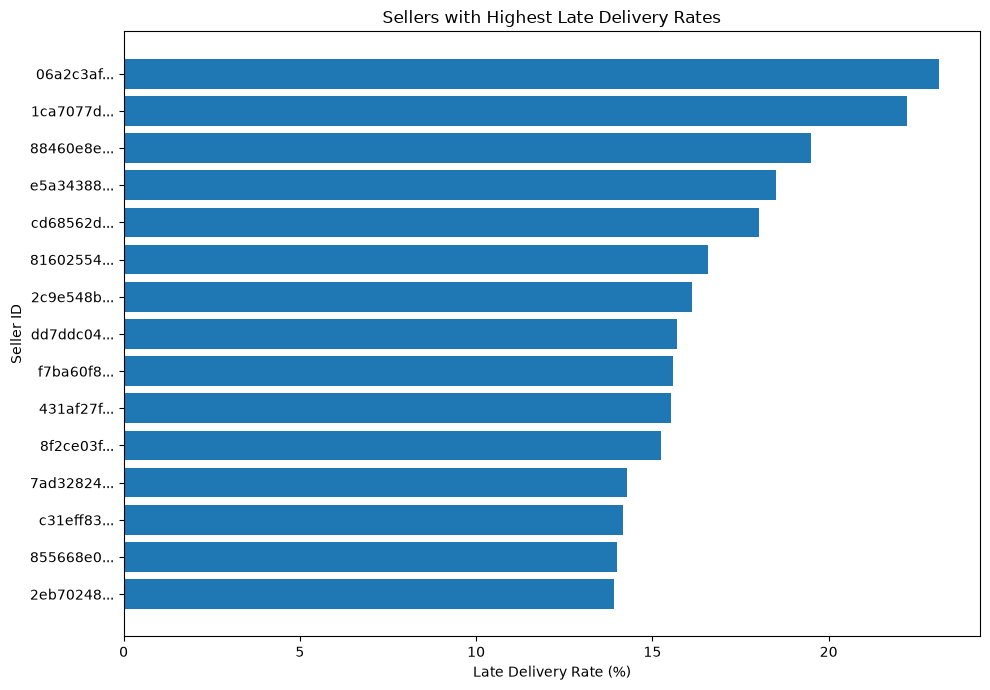

In [38]:
seller_late_chart = (
    seller_performance_filtered
    .head(15)
    .copy()
)

seller_late_chart["seller_short"] = (
    seller_late_chart["seller_id"].str[:8] + "..."
)

seller_late_chart = seller_late_chart.sort_values(
    "late_rate_pct",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    seller_late_chart["seller_short"],
    seller_late_chart["late_rate_pct"]
)

plt.title("Sellers with Highest Late Delivery Rates")
plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Seller ID")
plt.tight_layout()

plt.show()

## 9. Payment & Transaction Patterns

Payment behavior provides insight into how customers complete transactions across the marketplace.

This section examines payment-method usage, payment value, and installment behavior. Because a single order may contain multiple payment records or payment methods, record-level and order-level payment metrics are interpreted separately to avoid double counting.

In [39]:
fact_payments = pd.read_csv(
    "../Data/processed/fact_payments.csv"
)

print("Payment records:", len(fact_payments))
print("Unique orders:", fact_payments["order_id"].nunique())
print("Payment types:", fact_payments["payment_type"].nunique())

Payment records: 103886
Unique orders: 99440
Payment types: 5


In [40]:
payment_type_summary = (
    fact_payments
    .groupby("payment_type")
    .agg(
        payment_records=("order_id", "count"),
        unique_orders=("order_id", "nunique"),
        total_payment_value=("payment_value", "sum"),
        average_payment_value=("payment_value", "mean")
    )
    .sort_values("unique_orders", ascending=False)
)

payment_type_summary.round(2)

,payment_records,unique_orders,total_payment_value,average_payment_value
payment_type,,,,
credit_card,76795,76505,12542084.19,163.32
boleto,19784,19784,2869361.27,145.03
voucher,5775,3866,379436.87,65.70
debit_card,1529,1528,217989.79,142.57
not_defined,3,3,0.00,0.00


In [41]:
credit_card_payments = fact_payments[
    fact_payments["payment_type"] == "credit_card"
].copy()

installment_summary = (
    credit_card_payments["payment_installments"]
    .value_counts()
    .sort_index()
    .to_frame("payment_records")
)

installment_summary["percentage"] = (
    installment_summary["payment_records"]
    / len(credit_card_payments)
    * 100
).round(2)

installment_summary

,payment_records,percentage
payment_installments,,
0,2,0.00
1,25455,33.15
2,12413,16.16
3,10461,13.62
4,7098,9.24
5,5239,6.82
6,3920,5.10
7,1626,2.12
8,4268,5.56


## 10. Repeat Customer Behavior

Customer retention is evaluated using `customer_unique_id`, which identifies the same customer across different order records.

For this analysis, repeat customers are defined as customers with at least two delivered orders. Using delivered orders prevents canceled, unavailable, or incomplete transactions from being counted as completed repeat purchases.

In [42]:
customer_order_frequency = (
    fact_orders[
        fact_orders["order_status"] == "delivered"
    ]
    .groupby("customer_unique_id")
    .agg(
        delivered_orders=("order_id", "count")
    )
    .reset_index()
)

customer_order_frequency["is_repeat_customer"] = (
    customer_order_frequency["delivered_orders"] >= 2
)

print("Customers with delivered orders:", len(customer_order_frequency))
print(
    "Repeat customers:",
    customer_order_frequency["is_repeat_customer"].sum()
)
print(
    "Maximum delivered orders by one customer:",
    customer_order_frequency["delivered_orders"].max()
)

Customers with delivered orders: 93358
Repeat customers: 2801
Maximum delivered orders by one customer: 15


In [43]:
total_customers = len(customer_order_frequency)

repeat_customers = (
    customer_order_frequency["is_repeat_customer"].sum()
)

repeat_customer_rate = (
    repeat_customers / total_customers * 100
)

orders_from_repeat_customers = (
    customer_order_frequency.loc[
        customer_order_frequency["is_repeat_customer"],
        "delivered_orders"
    ].sum()
)

total_delivered_orders = (
    customer_order_frequency["delivered_orders"].sum()
)

repeat_order_share = (
    orders_from_repeat_customers
    / total_delivered_orders
    * 100
)

print("Total customers:", total_customers)
print("Repeat customers:", repeat_customers)
print(f"Repeat customer rate: {repeat_customer_rate:.2f}%")
print("Total delivered orders:", total_delivered_orders)
print(
    "Orders from repeat customers:",
    orders_from_repeat_customers
)
print(
    f"Share of delivered orders from repeat customers: "
    f"{repeat_order_share:.2f}%"
)

Total customers: 93358
Repeat customers: 2801
Repeat customer rate: 3.00%
Total delivered orders: 96478
Orders from repeat customers: 5921
Share of delivered orders from repeat customers: 6.14%


In [44]:
customer_frequency_distribution = (
    customer_order_frequency["delivered_orders"]
    .value_counts()
    .sort_index()
    .to_frame("customer_count")
)

customer_frequency_distribution["percentage"] = (
    customer_frequency_distribution["customer_count"]
    / len(customer_order_frequency)
    * 100
).round(2)

customer_frequency_distribution

,customer_count,percentage
delivered_orders,,
1,90557,97.00
2,2573,2.76
3,181,0.19
4,28,0.03
5,9,0.01
6,5,0.01
7,3,0.00
9,1,0.00
15,1,0.00


## 11. Key Findings

The exploratory analysis identified several important operational and customer-experience patterns in the Olist marketplace:

### Delivery Performance
- 97.02% of all recorded orders reached delivered status.
- Among 96,470 delivered orders with measurable delivery performance, 8.11% arrived after the estimated delivery date.
- Median delivery time was 10.22 days, while delivered orders arrived approximately 11.18 days earlier than the estimated date on average.
- Among late orders, 57.25% arrived no more than seven days late, while 19.87% were more than 14 days late.

### Delivery and Customer Satisfaction
- Delivery performance was strongly associated with customer review scores.
- On-time deliveries received an average review score of 4.29, compared with only 2.57 for late deliveries.
- More severe delays were generally associated with substantially lower customer satisfaction.
- Late orders showed longer times in both pre-carrier processing and carrier transit, with the largest difference appearing in the transit stage.

### Geographic Performance
- Delivery performance varied substantially across Brazilian states.
- Among states with at least 300 delivered orders, late-delivery rates ranged from 5.00% in PR to 23.93% in AL.
- High-volume markets such as RJ and BA combined meaningful order volume with relatively high late-delivery rates, making them operationally important areas for further investigation.

### Product Categories
- Bed, bath & table had the highest number of category-associated orders, while health & beauty generated the highest transaction value among the leading categories.
- Among categories with at least 300 delivered orders, audio had the highest late-delivery rate at 12.93%.
- Office furniture stood out for its combination of relatively high late delivery, a long median delivery time of 18.86 days, and a low average review score of 3.64.
- Category delivery metrics represent orders associated with each category and should not be interpreted as exclusive causal attribution when orders contain multiple categories.

### Seller Performance
- Seller performance varied considerably even among high-volume sellers.
- Among sellers with at least 100 delivered orders, several were associated with late-delivery rates above 15%.
- One seller with 389 delivered orders had a 23.14% late-delivery rate.
- Some underperforming sellers also showed notably low review scores, indicating potential seller-associated operational and customer-experience risks.
- Because some orders contain multiple sellers, these metrics represent seller-associated outcomes rather than direct causal responsibility.

### Payment Behavior
- Credit cards were the dominant payment method, appearing in 76,505 orders and representing approximately 12.54 million in recorded payment value.
- Boleto was the second most widely used payment method.
- One-installment payments were the most common credit-card configuration, representing 33.15% of credit-card payment records, while installment purchasing remained widely used overall.
- Multiple payment records and mixed payment methods exist, so payment-record metrics should not be interpreted directly as unique-order counts.

### Repeat Customer Behavior
- Only 3.00% of customers with at least one delivered order made two or more delivered purchases during the observed dataset period.
- Repeat customers generated 6.14% of delivered orders.
- 97.00% of customers made exactly one delivered purchase, indicating that marketplace activity in the observed period was dominated by one-time purchasers.

Overall, the analysis suggests that delivery reliability is one of the strongest operational signals associated with customer satisfaction. Regional, category, and seller-level differences provide clear opportunities for deeper operational investigation, while the low observed repeat-purchase rate highlights customer retention as another important area for business analysis.